In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


In [3]:
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


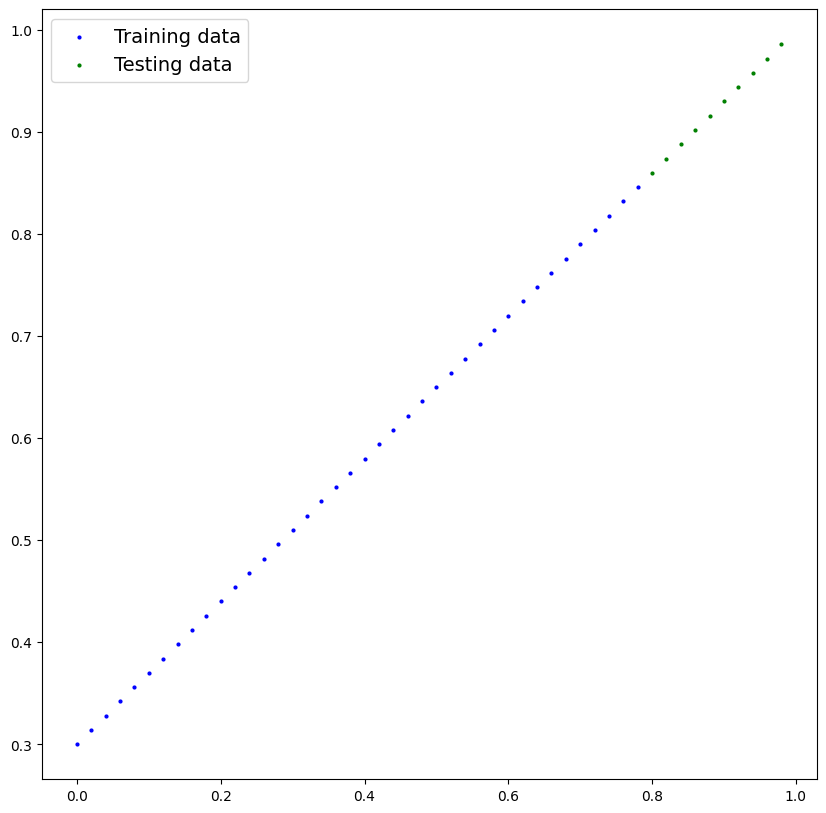

In [4]:
def plot_predictions(train_data = X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
  plt.figure(figsize=(10, 10))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
  plt.legend(prop={"size": 14});

plot_predictions();

In [5]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

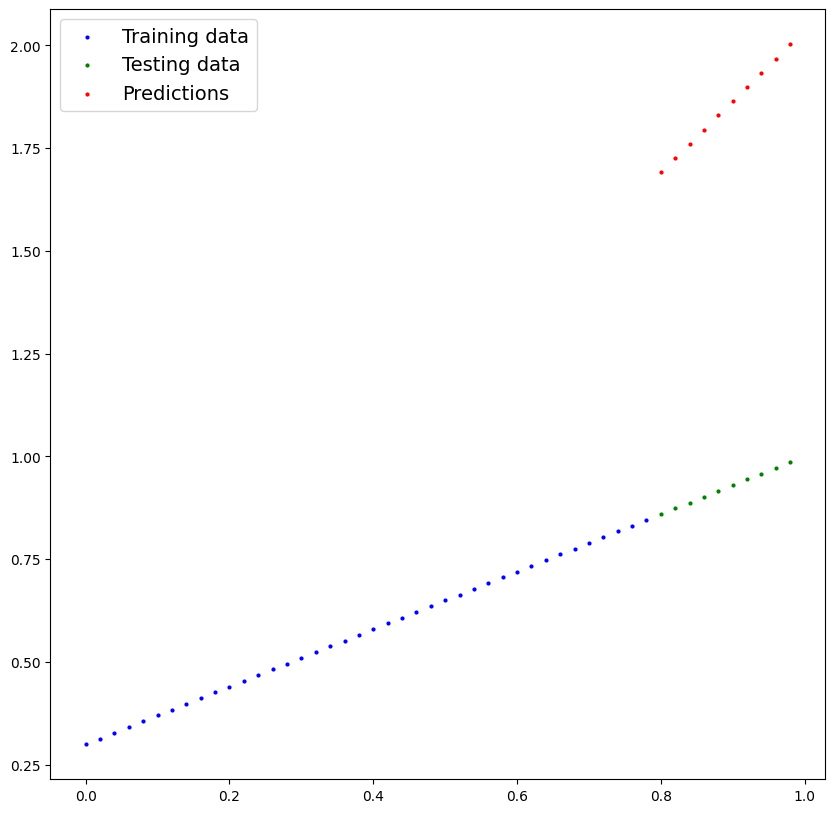

In [6]:
model = Model()

model.eval()
with torch.no_grad():
  preds = model(X_test)

plot_predictions(predictions=preds)

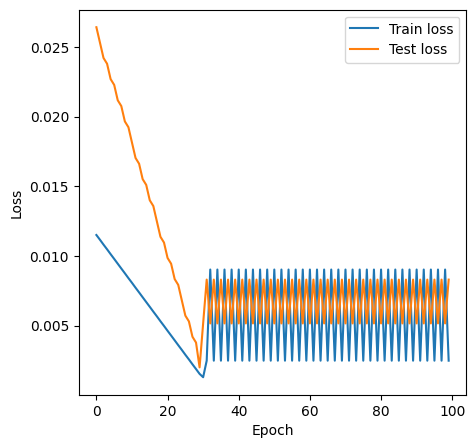

In [13]:
loss_func = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

model.train()
epoch = 100
losses = {i: (0, 0) for i in range(epoch)}

for i in range(epoch):
  pred = model(X_train)
  optimizer.zero_grad()
  train_loss = loss_func(pred, y_train)
  train_loss.backward()
  optimizer.step()

  with torch.inference_mode():
    preds = model(X_test)
    test_loss = loss_func(preds, y_test)
    losses[i] = (train_loss.item(), test_loss.item())

plt.figure(figsize=(5,5))
epochs = list(losses.keys())

train_losses = [losses[i][0] for i in epochs]
test_losses = [losses[i][1] for i in epochs]

plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


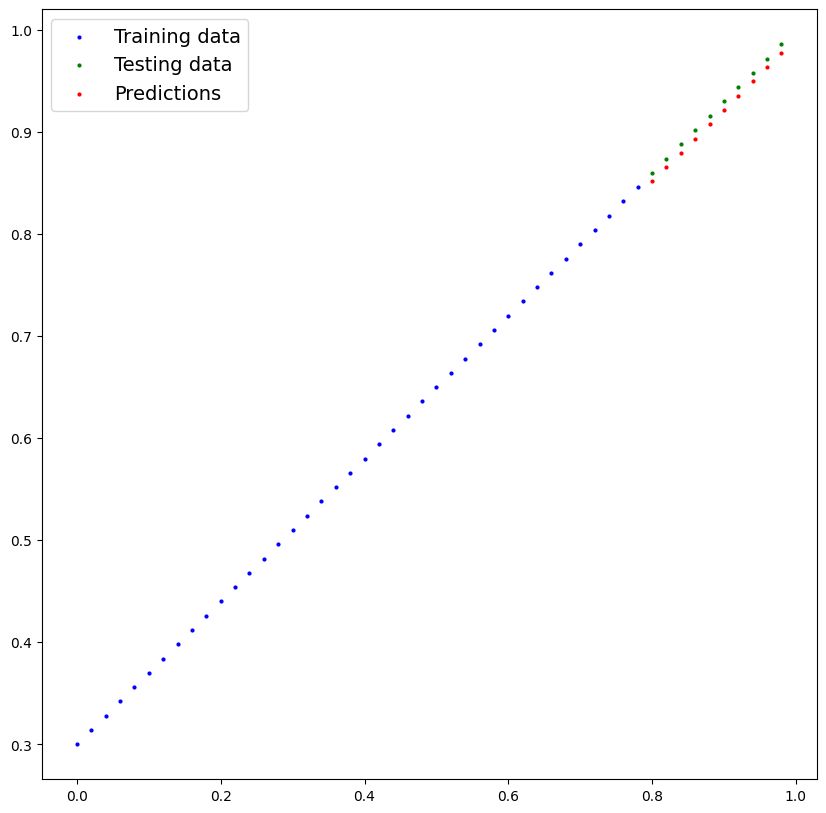

In [14]:
model.eval()
with torch.no_grad():
  preds = model(X_test)

plot_predictions(predictions=preds)

In [15]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "kgx.pth"
SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(model.state_dict(), SAVE_PATH)